In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [2]:
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid") #global style for every chart 
plt.rcParams['figure.figsize'] = (10,5) #default size for every chart
pd.set_option('display.max_columns',50) 

In [3]:
trades = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")

In [4]:
print("Trade shape:", trades.shape)

Trade shape: (211224, 16)


In [5]:
print("Sentiment shape:", sentiment.shape)

Sentiment shape: (2644, 4)


In [6]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [7]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [8]:
#Check for missing data and data types

In [9]:
print(trades.isna().sum())

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


In [10]:
print(sentiment.isna().sum())

timestamp         0
value             0
classification    0
date              0
dtype: int64


In [11]:
#checking the datatypes
print(trades.dtypes)

Account              object
Coin                 object
Execution Price     float64
Size Tokens         float64
Size USD            float64
Side                 object
Timestamp IST        object
Start Position      float64
Direction            object
Closed PnL          float64
Transaction Hash     object
Order ID              int64
Crossed                bool
Fee                 float64
Trade ID            float64
Timestamp           float64
dtype: object


In [12]:
#converting the timestamp into a real datetime

In [13]:
trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], format='%d-%m-%Y %H:%M')

In [14]:
#converting a column with only date

In [15]:
trades['date'] = pd.to_datetime(trades['Timestamp IST'].dt.date)

In [16]:
#converting the sentiment dataset date column to real dateime

In [17]:
sentiment['date'] = pd.to_datetime(sentiment['date'])

In [18]:
sentiment_order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
sentiment['classification'] = pd.Categorical(
    sentiment['classification'], categories=sentiment_order, ordered=True
)

In [19]:
print(trades['date'].min(), "to", trades['date'].max())


2023-05-01 00:00:00 to 2025-05-01 00:00:00


In [20]:
print(sentiment['date'].min(), "to", sentiment['date'].max())


2018-02-01 00:00:00 to 2025-05-02 00:00:00


In [21]:
df = trades.merge(sentiment[['date', 'value', 'classification']], on='date', how='left')

In [22]:
unmatched = df['classification'].isna().sum()
print(f"Unmatched trades: {unmatched} ({unmatched/len(df):.2%})")

Unmatched trades: 6 (0.00%)


In [23]:
df = df.dropna(subset=['classification'])
print("Final merged shape:", df.shape)

Final merged shape: (211218, 19)


In [24]:
!pip install --upgrade matplotlib_inline matplotlib

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [25]:
import sys
print(sys.executable)

c:\users\sneha jadhav\appdata\local\programs\python\python39\python.exe


In [26]:
%pip install --upgrade matplotlib_inline matplotlib --user

Note: you may need to restart the kernel to use updated packages.


In [27]:
#This chart shows how much total dollar volume was traded each day across the whole year.

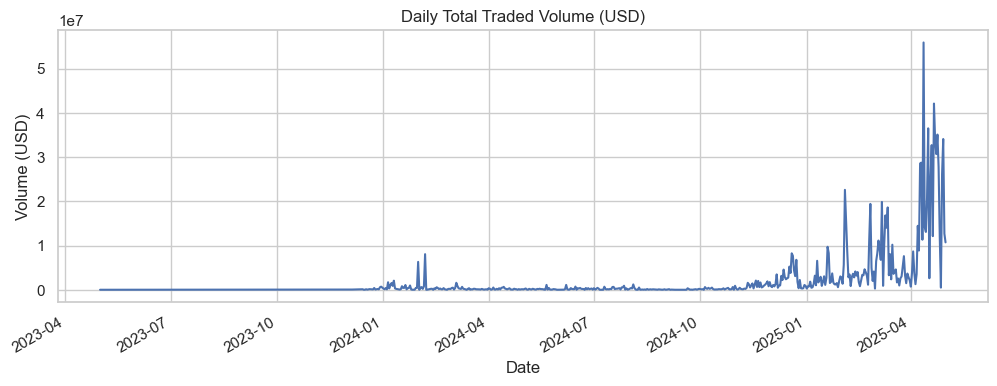

In [28]:
daily_volume = trades.groupby('date')['Size USD'].sum()

plt.figure(figsize=(12, 4))
daily_volume.plot()
plt.title('Daily Total Traded Volume (USD)')
plt.xlabel('Date')
plt.ylabel('Volume (USD)')
plt.show()

#trading volume was near-flat and tiny for most of 2023–2024,
#then ramped up sharply from late 2024 into 2025, 
#with big spikes especially around March–April 2025.

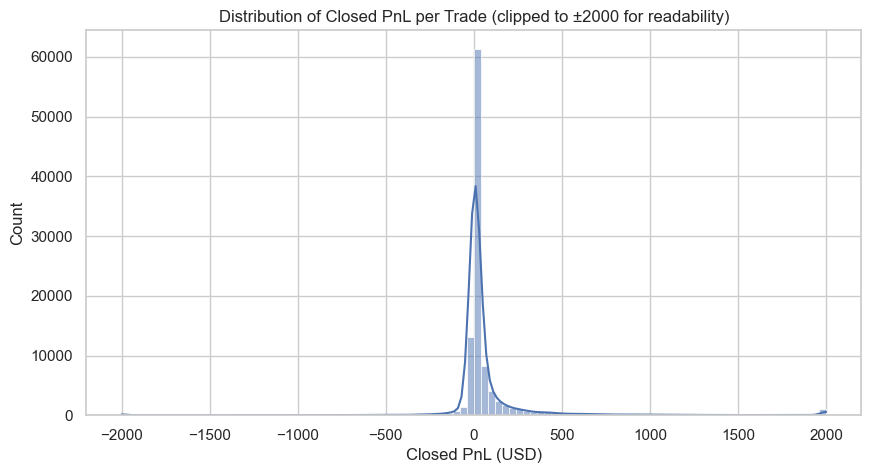

count    104408.000000
mean         98.622318
std        1305.489556
min     -117990.104100
25%           0.413069
50%           6.055500
75%          38.197947
max      135329.090100
Name: Closed PnL, dtype: float64


In [32]:
nonzero_pnl = trades.loc[trades['Closed PnL'] != 0, 'Closed PnL']

plt.figure(figsize=(10, 5))
sns.histplot(nonzero_pnl.clip(-2000, 2000), bins=100, kde=True)
plt.title('Distribution of Closed PnL per Trade (clipped to ±2000 for readability)')
plt.xlabel('Closed PnL (USD)')
plt.show()

print(nonzero_pnl.describe())


#out of 104,408 closed trades, the average PnL was +$98.62, 
#but the median was only +$6.06 — meaning most trades netted a tiny profit,
#and the high average is being pulled up by a smaller number of big winning trades.

                   total_pnl   mean_pnl  median_pnl  trade_count
classification                                                  
Extreme Fear    7.391102e+05  34.537862         0.0        21400
Fear            3.357155e+06  54.290400         0.0        61837
Neutral         1.292921e+06  34.307718         0.0        37686
Greed           2.150129e+06  42.743559         0.0        50303
Extreme Greed   2.715171e+06  67.892861         0.0        39992


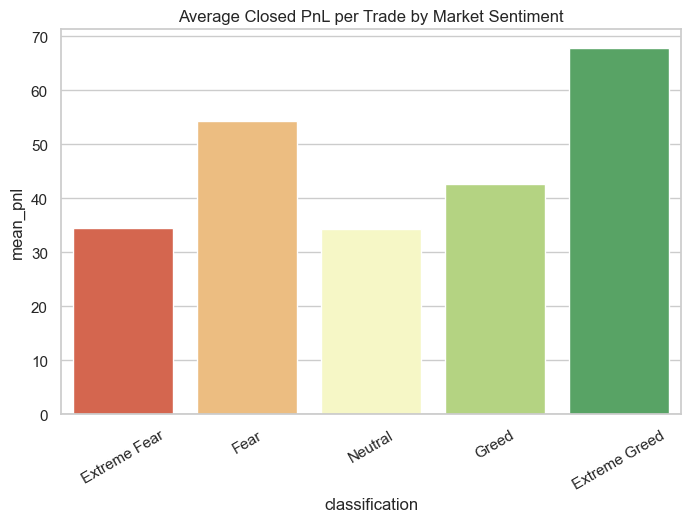

In [33]:
pnl_by_sentiment = df.groupby('classification', observed=True)['Closed PnL'].agg(
    total_pnl='sum', mean_pnl='mean', median_pnl='median', trade_count='count'
).reindex(sentiment_order)

print(pnl_by_sentiment)

plt.figure(figsize=(8, 5))
sns.barplot(x=pnl_by_sentiment.index, y=pnl_by_sentiment['mean_pnl'], palette='RdYlGn')
plt.title('Average Closed PnL per Trade by Market Sentiment')
plt.xticks(rotation=30)
plt.axhline(0, color='black', linewidth=0.8)
plt.show()



#Extreme Greed is the most profitable regime by far ($67.89/trade),
#but the second-best is Fear ($54.29) — even beating plain "Greed" ($42.74). 
#Neutral and Extreme Fear are the weakest, sitting almost tied around $34.

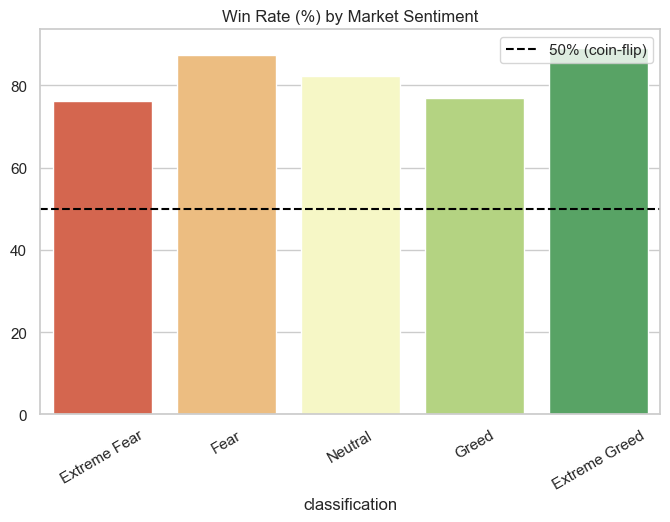

classification
Extreme Fear     0.762156
Fear             0.872886
Neutral          0.823889
Greed            0.768907
Extreme Greed    0.891670
Name: is_win, dtype: float64


In [35]:
closed_trades = df[df['Closed PnL'] != 0].copy()
closed_trades['is_win'] = closed_trades['Closed PnL'] > 0

win_rate = closed_trades.groupby('classification', observed=True)['is_win'].mean().reindex(sentiment_order)

plt.figure(figsize=(8, 5))
sns.barplot(x=win_rate.index, y=win_rate.values * 100, palette='RdYlGn')
plt.title('Win Rate (%) by Market Sentiment')
plt.axhline(50, color='black', linestyle='--', label='50% (coin-flip)')
plt.xticks(rotation=30)
plt.legend()
plt.show()

print(win_rate)


#Every regime is well above the 50% coin-flip line - this trader population wins,
#the large majority of their trades overall, which itself says something (likely disciplined risk management or exit strategy, not just random luck).
#But Fear and Extreme Greed are clearly the two strongest win-rate regimes (87–89%), while plain "Greed" is actually the weakest (76.9%, barely above Extreme Fear).

                  mean_size  median_size
classification                          
Extreme Fear    5349.731843      766.150
Fear            7816.109931      735.960
Neutral         4782.732661      547.655
Greed           5736.884375      555.000
Extreme Greed   3112.251565      500.050


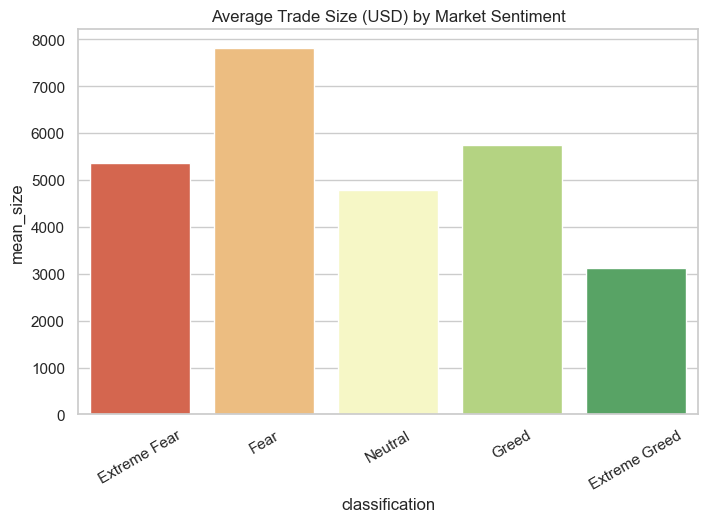

In [36]:
size_by_sentiment = df.groupby('classification', observed=True)['Size USD'].agg(
    mean_size='mean', median_size='median'
).reindex(sentiment_order)

print(size_by_sentiment)

plt.figure(figsize=(8, 5))
sns.barplot(x=size_by_sentiment.index, y=size_by_sentiment['mean_size'], palette='RdYlGn')
plt.title('Average Trade Size (USD) by Market Sentiment')
plt.xticks(rotation=30)
plt.show()

# Traders bet their biggest during Fear ($7,816 avg) 
#and their smallest during Extreme Greed ($3,112 avg) 
#yet Extreme Greed had the highest win rate and PnL/trade (Steps 13–14), while Fear-sized-up trades still did well but not as well per-dollar.

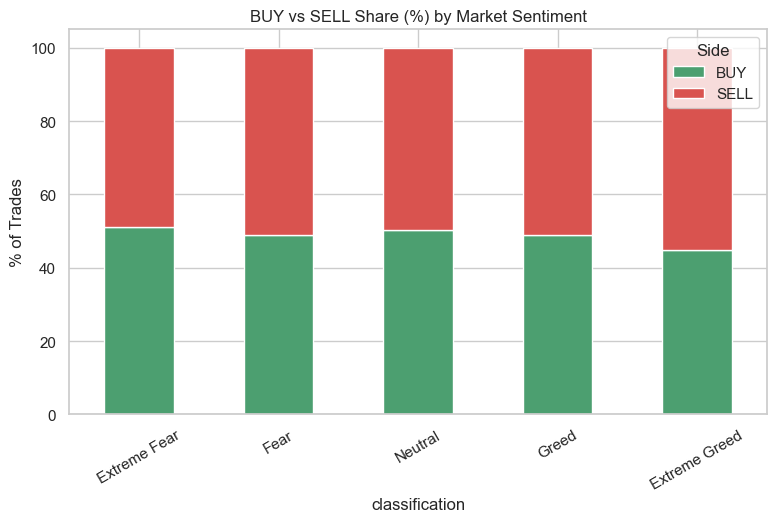

Side                  BUY       SELL
classification                      
Extreme Fear    51.098131  48.901869
Fear            48.951275  51.048725
Neutral         50.334342  49.665658
Greed           48.855933  51.144067
Extreme Greed   44.858972  55.141028


In [37]:
side_by_sentiment = pd.crosstab(df['classification'], df['Side'], normalize='index') * 100
side_by_sentiment = side_by_sentiment.reindex(sentiment_order)

side_by_sentiment.plot(kind='bar', stacked=True, figsize=(9, 5), color=['#4C9F70', '#D9534F'])
plt.title('BUY vs SELL Share (%) by Market Sentiment')
plt.xticks(rotation=30)
plt.ylabel('% of Trades')
plt.show()

print(side_by_sentiment)


#Most sentiment regimes sit close to a 50/50 BUY/SELL split — 
#direction isn't strongly driven by daily mood most of the time.
#The one exception is Extreme Greed, where SELL share rises to 55.1% (the highest of any regime) — meaning traders 
#leaned noticeably more toward selling when the market was most euphoric. 

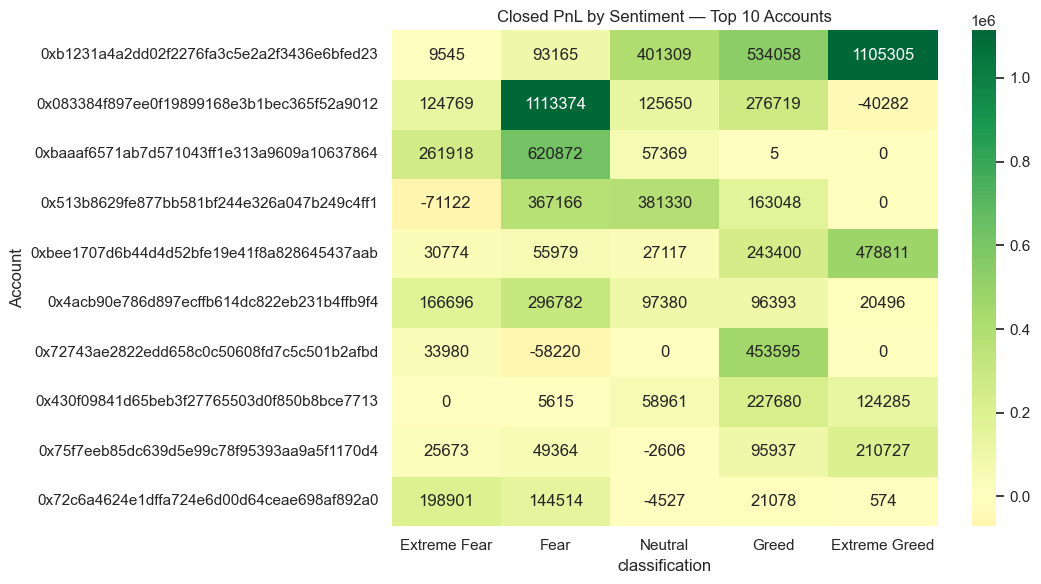

In [38]:
account_sentiment_pnl = (
    df.groupby(['Account', 'classification'], observed=True)['Closed PnL']
    .sum()
    .unstack(fill_value=0)
    .reindex(columns=sentiment_order, fill_value=0)
)

top_accounts = df.groupby('Account')['Closed PnL'].sum().sort_values(ascending=False).head(10).index

plt.figure(figsize=(11, 6))
sns.heatmap(account_sentiment_pnl.loc[top_accounts], cmap='RdYlGn', center=0, annot=True, fmt='.0f')
plt.title('Closed PnL by Sentiment — Top 10 Accounts')
plt.tight_layout()
plt.show()

In [39]:
fear_cols = ['Extreme Fear', 'Fear']
greed_cols = ['Greed', 'Extreme Greed']

account_profile = pd.DataFrame({
    'fear_pnl': account_sentiment_pnl[fear_cols].sum(axis=1),
    'greed_pnl': account_sentiment_pnl[greed_cols].sum(axis=1),
    'neutral_pnl': account_sentiment_pnl['Neutral'],
})
account_profile['total_pnl'] = account_profile.sum(axis=1)
account_profile['style'] = np.where(
    account_profile['fear_pnl'] > account_profile['greed_pnl'],
    'Fear-favoring (contrarian)', 'Greed-favoring (momentum)'
)

print(account_profile['style'].value_counts())
account_profile.sort_values('total_pnl', ascending=False)

Greed-favoring (momentum)     21
Fear-favoring (contrarian)    11
Name: style, dtype: int64


,fear_pnl,greed_pnl,neutral_pnl,total_pnl,style
Account,,,,,
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,1.027101e+05,1.639363e+06,401309.434693,2.143383e+06,Greed-favoring (momentum)
0x083384f897ee0f19899168e3b1bec365f52a9012,1.238143e+06,2.364369e+05,125650.116740,1.600230e+06,Fear-favoring (contrarian)
0xbaaaf6571ab7d571043ff1e313a9609a10637864,8.827904e+05,4.672458e+00,57368.780126,9.401638e+05,Fear-favoring (contrarian)
0x513b8629fe877bb581bf244e326a047b249c4ff1,2.960444e+05,1.630477e+05,381330.494050,8.404226e+05,Fear-favoring (contrarian)
0xbee1707d6b44d4d52bfe19e41f8a828645437aab,8.675289e+04,7.222110e+05,27116.682664,8.360806e+05,Greed-favoring (momentum)
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4,4.634781e+05,1.168888e+05,97380.090931,6.777471e+05,Fear-favoring (contrarian)
0x72743ae2822edd658c0c50608fd7c5c501b2afbd,-2.423975e+04,4.535953e+05,0.000000,4.293556e+05,Greed-favoring (momentum)
0x430f09841d65beb3f27765503d0f850b8bce7713,5.615052e+03,3.519654e+05,58961.379730,4.165419e+05,Greed-favoring (momentum)
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4,7.503711e+04,3.066642e+05,-2605.956471,3.790954e+05,Greed-favoring (momentum)


                     avg_sentiment_value  total_daily_pnl  avg_trade_size
avg_sentiment_value             1.000000        -0.082642       -0.051824
total_daily_pnl                -0.082642         1.000000       -0.015941
avg_trade_size                 -0.051824        -0.015941        1.000000


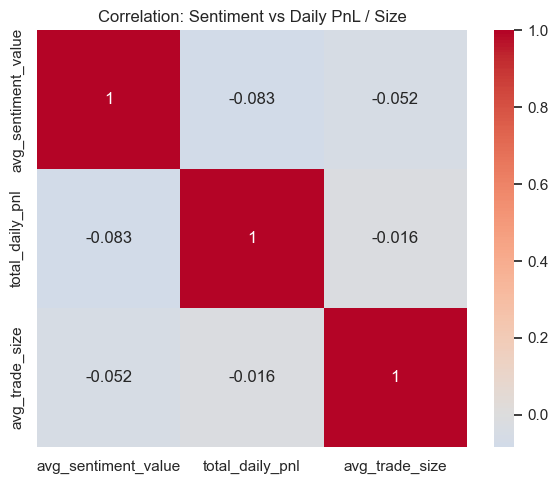

In [40]:
corr_df = df.groupby('date').agg(
    avg_sentiment_value=('value', 'mean'),
    total_daily_pnl=('Closed PnL', 'sum'),
    avg_trade_size=('Size USD', 'mean')
).reset_index()

correlation = corr_df[['avg_sentiment_value', 'total_daily_pnl', 'avg_trade_size']].corr()
print(correlation)

plt.figure(figsize=(6, 5))
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation: Sentiment vs Daily PnL / Size')
plt.tight_layout()
plt.show()

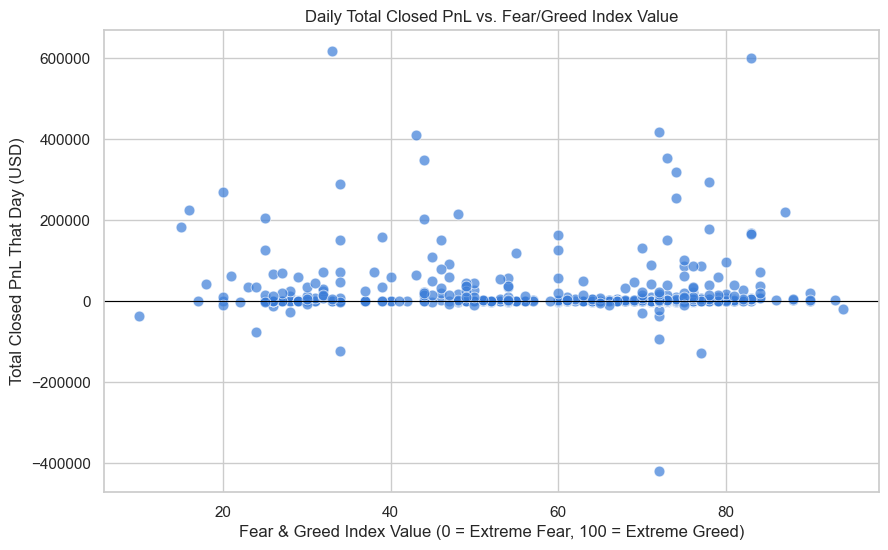

In [41]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=corr_df, x='avg_sentiment_value', y='total_daily_pnl',
    s=60, alpha=0.7, color='#3B7DD8'
)
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Daily Total Closed PnL vs. Fear/Greed Index Value')
plt.xlabel('Fear & Greed Index Value (0 = Extreme Fear, 100 = Extreme Greed)')
plt.ylabel('Total Closed PnL That Day (USD)')
plt.show()

In [42]:
import os
os.makedirs('output', exist_ok=True)

pnl_by_sentiment.to_csv('output/pnl_by_sentiment.csv')
win_rate.to_csv('output/win_rate_by_sentiment.csv')
size_by_sentiment.to_csv('output/size_by_sentiment.csv')
side_by_sentiment.to_csv('output/side_by_sentiment.csv')
account_profile.sort_values('total_pnl', ascending=False).to_csv('output/account_profile.csv')
correlation.to_csv('output/sentiment_correlation.csv')

print("Saved summary tables to the 'output/' folder:")
for f in os.listdir('output'):
    print(' -', f)

Saved summary tables to the 'output/' folder:
 - account_profile.csv
 - pnl_by_sentiment.csv
 - sentiment_correlation.csv
 - side_by_sentiment.csv
 - size_by_sentiment.csv
 - win_rate_by_sentiment.csv


## Key Insights: Trader Behavior vs. Market Sentiment

**1. Both extremes of sentiment beat the middle — it's not a straight line from Fear to Greed.**
Traders did best during Extreme Greed (avg PnL $67.89/trade, 89.2% win rate) and second-best
during plain Fear ($54.29/trade, 87.3% win rate). Neutral and Extreme Fear were the weakest,
both sitting around $34/trade and ~76% win rate. So the real pattern isn't "greed is good,
fear is bad" — it's that traders do better at either extreme and worse in the middle.

**2. Traders actually size up during Fear, not Greed.**
Average trade size was biggest during Fear ($7,816) and smallest during Extreme Greed
($3,112). That's the opposite of what you'd expect if people were chasing hype — instead
it looks like traders were buying dips with real conviction, and getting more cautious with
their bet sizes exactly when the market was most euphoric.

**3. Buy/sell direction barely moves with sentiment, except at the very top.**
Across most sentiment levels the buy/sell split stayed close to 50/50. The one exception was
Extreme Greed, where sell share climbed to 55.1% — traders leaned more defensive right when
the crowd was most greedy.

**4. About two-thirds of traders are momentum-driven, one-third contrarian.**
21 of the 32 accounts made more money overall on Greed-side days, and 11 made more on
Fear-side days. A few accounts are extreme examples of each: one made over $1.1M specifically
during Fear, another made over $1M specifically during Extreme Greed. These aren't random
swings — they look like genuinely different trading styles.

**5. Sentiment score alone barely predicts daily PnL (correlation -0.08).**
This doesn't undercut the findings above, it just explains why a simple straight-line
correlation misses them. The real relationship is shaped like a U across the five sentiment
categories, not a straight line, so a single correlation number can't capture it. The
takeaway: sentiment matters, but only as a category, not as a smooth numeric signal.

## Recommendations for a Smarter Trading Strategy

- Don't default to "buy the greed, sell the fear" as a blanket rule — both sentiment
  extremes performed better than the neutral middle for this trader population.
- Be more cautious sizing up during Neutral or mildly-fearful days, since that's where
  performance was weakest.
- Even though Extreme Greed had the best win rate, keep position sizes capped there —
  the scatter plot showed one day with a $400K+ loss during a greed-leaning period, so the
  upside comes with real tail risk.
- Treat traders differently based on their style. A third of the accounts here are
  consistently better in fear-driven markets, so a single sentiment-based strategy applied
  to everyone would likely hurt that group.